# Build a Mobility Lakehouse: AIS trajectories on Iceberg

This notebook builds a small **mobility lakehouse** end to end with **MobilityDuck**,
the DuckDB extension behind the live
[AIS Iceberg Explorer](https://ais-explorer-833836401560.europe-west1.run.app/):

1. ingest raw AIS pings and build typed trajectories,
2. write a **TemporalParquet** shard — a lossless value column plus **covering columns**,
3. query it **pruned** by space and time,
4. verify the cross-engine round-trip,
5. promote it to an Apache Iceberg table.

It is meant to be **run**: every cell executes against a real MobilityDuck engine.

## Setup

You need a **MobilityDuck-enabled DuckDB** — the same engine the AIS Iceberg
Explorer runs on. Either:

- install the published extension: `INSTALL mobilityduck FROM community; LOAD mobilityduck;`, or
- build it from the pinned [MobilityDuck](https://github.com/MobilityDB/MobilityDuck) source.

Point the `MOBILITYDUCK` environment variable at that DuckDB executable before
launching Jupyter (it defaults to `duckdb` on your `PATH`). The helper below runs
SQL against it and returns a pandas `DataFrame`, keeping state in one database file
so the cells compose.

In [1]:
import os, json, subprocess, pandas as pd

MOBILITYDUCK = os.environ.get("MOBILITYDUCK", "duckdb")   # a MobilityDuck-enabled DuckDB CLI
DB = "mobility_lakehouse.duckdb"                            # persistent across cells

def duck(sql: str) -> pd.DataFrame:
    r = subprocess.run([MOBILITYDUCK, DB, "-json", "-c", sql],
                       capture_output=True, text=True)
    if r.returncode:
        raise RuntimeError(r.stderr.strip())
    return pd.DataFrame(json.loads(r.stdout or "[]"))

# smoke test: a temporal point round-trips through the engine
duck("""SELECT asText(tgeompoint
        '[Point(0 0)@2020-01-01, Point(1 1)@2020-01-01 01:00:00]') AS smoke""")

,smoke
0,"[POINT(0 0)@2020-01-01 00:00:00+01, POINT(1 1)..."


## 1. Ingest raw AIS pings → typed trajectories

Each vessel's stream of `(time, lon, lat)` pings becomes one `tgeogpoint`
trajectory — a function from time to space, not a pile of points.

In [2]:
duck("""
CREATE OR REPLACE TABLE raw(mmsi BIGINT, ts TIMESTAMPTZ, lon DOUBLE, lat DOUBLE);
INSERT INTO raw VALUES
  (211512000,'2026-02-26 08:00:00+00',4.40,51.20),
  (211512000,'2026-02-26 09:00:00+00',4.62,51.31),
  (211512000,'2026-02-26 10:30:00+00',4.95,51.48),
  (244660000,'2026-02-26 08:15:00+00',3.10,51.95),
  (244660000,'2026-02-26 09:20:00+00',3.55,52.02),
  (244660000,'2026-02-26 11:00:00+00',4.05,52.20);
""")

duck("""
CREATE OR REPLACE TABLE trajectories AS
SELECT mmsi,
       tgeogpointSeq(list(TGEOGPOINT(ST_Point(lon, lat), ts) ORDER BY ts)) AS traj
FROM raw GROUP BY mmsi;
""")

duck("SELECT mmsi, numInstants(traj) AS pings, duration(traj) AS span FROM trajectories ORDER BY mmsi")

,mmsi,pings,span
0,211512000,3,02:30:00
1,244660000,3,02:45:00


## 2. Write a TemporalParquet shard with covering columns

The trajectory is stored as a lossless `BYTE_ARRAY` (MEOS-WKB). Alongside it we
materialise primitive **covering columns** — the bounding box and time extent —
so Parquet and Iceberg can prune without decoding any trajectory.

In [3]:
duck("""
COPY (
  SELECT mmsi,
         asBinary(traj)    AS traj,                 -- canonical value (BLOB)
         Xmin(stbox(traj)) AS xmin, Xmax(stbox(traj)) AS xmax,
         Ymin(stbox(traj)) AS ymin, Ymax(stbox(traj)) AS ymax,
         Tmin(stbox(traj)) AS tmin, Tmax(stbox(traj)) AS tmax,
         SRID(traj)        AS srid
  FROM trajectories
) TO 'ais_shard.parquet' (FORMAT PARQUET);
""")

# the value column is an opaque BLOB; the covering columns are plain primitives
duck("""SELECT name, type FROM parquet_schema('ais_shard.parquet')
         WHERE name IN ('traj','xmin','xmax','tmin','tmax','srid') ORDER BY name""")

,name,type
0,srid,INT32
1,tmax,INT64
2,tmin,INT64
3,traj,BYTE_ARRAY
4,xmax,DOUBLE
5,xmin,DOUBLE


The covering columns hold the **real** double-precision bounds (the value column
keeps full precision; only the text rendering of a trajectory is rounded):

In [4]:
duck("""SELECT mmsi, xmin, xmax, ymin, ymax, srid FROM read_parquet('ais_shard.parquet')
         ORDER BY mmsi""")

,mmsi,xmin,xmax,ymin,ymax,srid
0,211512000,4.4,4.95,51.20,51.48,4326
1,244660000,3.1,4.05,51.95,52.20,4326


## 3. Query it: pruned by space and time

A bounding-box-and-time predicate is a scalar AND-chain over the covering columns.
The engine evaluates it against column statistics and skips non-intersecting files
and row groups, with **no spatial-aware engine and no spatial extension**. Here the
window over the Scheldt approaches keeps vessel `211512000` and prunes `244660000`.

In [5]:
duck("""
SELECT mmsi, numInstants(tgeogpointFromBinary(traj)) AS pings
FROM read_parquet('ais_shard.parquet')
WHERE tmax >= TIMESTAMPTZ '2026-02-26' AND tmin < TIMESTAMPTZ '2026-02-27'
  AND xmax >= 4.5 AND xmin <= 5.0
  AND ymax >= 51.0 AND ymin <= 51.6
ORDER BY mmsi
""")

,mmsi,pings
0,211512000,3


## 4. Verify the cross-engine round-trip

The value column is reconstructed from MEOS-WKB with no conversion. The bounds
computed from the reconstructed trajectory match the covering columns exactly —
the storage is lossless.

In [6]:
duck("""
WITH back AS (
  SELECT mmsi, tgeogpointFromBinary(traj) AS traj, xmin, xmax, ymin, ymax
  FROM read_parquet('ais_shard.parquet')
)
SELECT mmsi,
       Xmin(stbox(traj)) = xmin AND Xmax(stbox(traj)) = xmax
   AND Ymin(stbox(traj)) = ymin AND Ymax(stbox(traj)) = ymax AS lossless
FROM back ORDER BY mmsi
""")

,mmsi,lossless
0,211512000,True
1,244660000,True


## A quick look at the trajectories

Plotted from the raw pings (the lakehouse keeps the full-precision geometry).

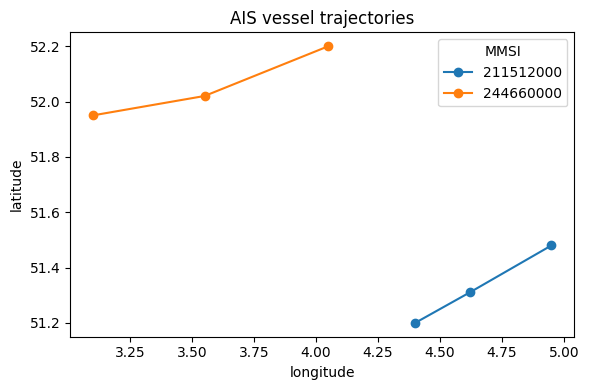

In [7]:
import matplotlib.pyplot as plt

raw = duck("SELECT mmsi, ts, lon, lat FROM raw ORDER BY mmsi, ts")
fig, ax = plt.subplots(figsize=(6, 4))
for mmsi, g in raw.groupby("mmsi"):
    ax.plot(g["lon"], g["lat"], marker="o", label=str(mmsi))
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("AIS vessel trajectories"); ax.legend(title="MMSI")
plt.tight_layout(); plt.show()

## 5. Promote to an Apache Iceberg table

Registering the shard tree as an Iceberg table adds snapshots, schema evolution,
time travel, and a REST catalog over the same files. The covering columns become
Iceberg column statistics, so the catalog prunes whole files at the **manifest**
level before a query reads them — this is the step the
[AIS Iceberg Explorer](https://ais-explorer-833836401560.europe-west1.run.app/)
runs over millions of AIS positions.

See the [format specification](../spec/temporalparquet.md) and
[covering columns](../spec/covering-columns.md) for the details, and
[getting-started.md](../getting-started.md) for the partitioning and catalog steps.